In [14]:
# Load dataset
import pandas as pd


df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

X = df.drop(['Attrition', 'Over18'], axis=1)
y = df['Attrition'].map({"Yes": 1, "No": 0})

# for col in X.select_dtypes(include='object').columns:
#     print(col, df[col].unique(), "\n")

print(X.info())

# print(f"{round((((y==0).sum()) / ((y==0).sum()+(y==1).sum()))*100, 2)}%")
# print(f"{round((((y==1).sum()) / ((y==0).sum()+(y==1).sum()))*100, 2)}%")

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   BusinessTravel            1470 non-null   str  
 2   DailyRate                 1470 non-null   int64
 3   Department                1470 non-null   str  
 4   DistanceFromHome          1470 non-null   int64
 5   Education                 1470 non-null   int64
 6   EducationField            1470 non-null   str  
 7   EmployeeCount             1470 non-null   int64
 8   EmployeeNumber            1470 non-null   int64
 9   EnvironmentSatisfaction   1470 non-null   int64
 10  Gender                    1470 non-null   str  
 11  HourlyRate                1470 non-null   int64
 12  JobInvolvement            1470 non-null   int64
 13  JobLevel                  1470 non-null   int64
 14  JobRole                   1470 non-null   str  
 15

In [6]:
# Split data into 80/20 ratio
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2,
    stratify=y
)

In [7]:
# Preprocess & Model's Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier


cate_cols = [col for col in X.select_dtypes(include='str').columns]

preprocess = ColumnTransformer(
    transformers = [
        ('encode_cols', OneHotEncoder(handle_unknown='ignore'), cate_cols)
    ],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('model', XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42))
])

In [8]:
# Fine tune hyperparameters(finding the best settings for the model)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.3, 0.5, 1],
    "model__reg_alpha": [0, 0.1, 0.5, 1],
    "model__reg_lambda": [1, 2, 5, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs_cv = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=3
)

In [9]:
# Train model
rs_cv.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.6, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best est

In [23]:
predictions = rs_cv.predict(X_test)
print(predictions)

best_estimator = rs_cv.best_estimator_
model = best_estimator.named_steps['model']
# print(model.feature_importances_)               # print feature importances score 

print(rs_cv.best_params_)                       # print the best hyperparameter found

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
{'model__subsample': 0.6, 'model__reg_lambda': 10, 'model__reg_alpha': 0, 'model__n_estimators': 200, 'model__min_child_weight': 7, 'model__max_depth': 6, 'model__learning_rate': 0.2, 'model__gamma': 0.5, 'model__colsample_bytree': 0.8}


In [11]:
# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, f1_score


print(classification_report(y_test, predictions))
print(f"\n\nCONFUSION MATRIX\n{confusion_matrix(y_test, predictions)}")

train_pred = rs_cv.predict(X_train)

# Training and Testing F1 Score
print(f"\n\nTrain F1 : {round(f1_score(y_train, train_pred)*100, 2)}%")
print(f"Test F1 : {round(f1_score(y_test, predictions)*100, 2)}%")


              precision    recall  f1-score   support

           0       0.88      0.97      0.92       247
           1       0.64      0.30      0.41        47

    accuracy                           0.86       294
   macro avg       0.76      0.63      0.66       294
weighted avg       0.84      0.86      0.84       294



CONFUSION MATRIX
[[239   8]
 [ 33  14]]


Train F1 : 83.68%
Test F1 : 40.58%


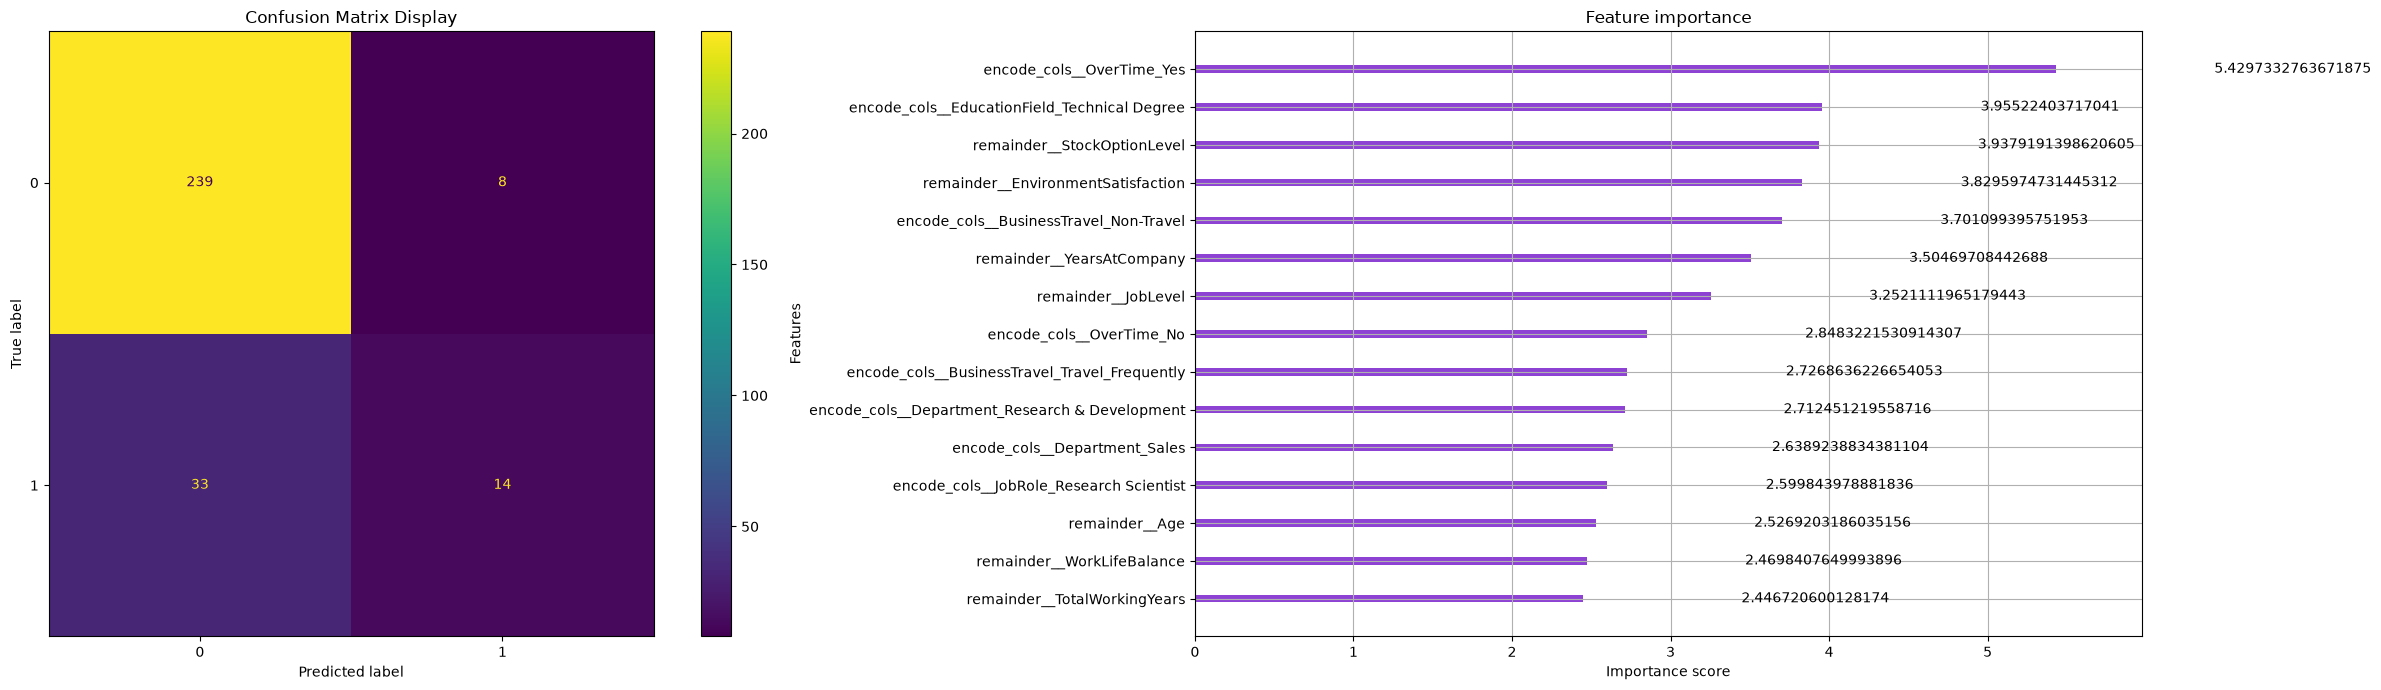

In [12]:
# Visualizations
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import xgboost as xgb


fig, axes = plt.subplots(1, 2, figsize=(25, 7))

# Visualize Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=axes[0])
axes[0].set_title("Confusion Matrix Display")

# Visualize XGBClassifier Feature Importance
encoded_features = best_estimator.named_steps['preprocessor'].get_feature_names_out()
model.get_booster().feature_names = list(encoded_features)

xgb.plot_importance(
    model,
    ax=axes[1],
    max_num_features=15,
    importance_type='gain',
    color="#8E42D4"
)

plt.tight_layout()